In [1]:
import pandas as pd 
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import json

In [2]:
data_dir = Path("../OptimizationInput")
base_load_df = pd.read_csv(data_dir / "alamedaBaseLoadDf_slice_month6_hour20.csv")
feeder_capacity_df = pd.read_csv(data_dir / "alamedaMinICA_slice_month6_hour20.csv")
# ev_load_df = pd.read_csv(data_dir / "ev_load_growth_from2025unmanaged_to2035managed_slice_hour_20.csv", dtype={"geoid": str})
ev_load_df = pd.read_csv(data_dir / "ev_load_growth_from2025unmanaged_to2035managed_max_slice_hour_20.csv", dtype={"geoid": str})
feeder_block_map_df = pd.read_csv(data_dir / "feederBlockIntersectionMtx.csv")
ev_network_df = pd.read_parquet(Path("../data/network_analysis/network_df.parquet"))

In [3]:
# Can use origin demand, assuming people charge before their next destination
# If I were to use destination demand, I would have to get it from the neighbors
ev_network_df['total_ev_load'] = ev_network_df['origin_demand_(kW)'] # + ev_network_df['destination_demand_(kW)']

In [4]:
total_ev_load_series = ev_network_df.set_index('geoid')['total_ev_load'].drop_duplicates()

In [5]:
# Trying with ev load from DF
feeder_loads = {}
for row in feeder_block_map_df.iterrows():
    feeder_loads[row[0]] = 0
    for block, proportion in row[1].items():
        # feeder_loads[row[0]] += proportion * ev_load_df.loc[ev_load_df['geoid'] == block, 'load'].values[0]
        feeder_loads[row[0]] += proportion * ev_network_df.loc[ev_network_df['geoid'] == block, 'total_ev_load'].values[0]

In [6]:
feeder_ev_load_series = pd.Series(feeder_loads)
feeder_ev_load_series = feeder_ev_load_series.rename('ev_load')

In [7]:
# Targeting 50% feeder overload based on Alan Jenn Paper, need to increase ev_load_df calculation by 4.7x
# feeder_ev_load_increased_series = feeder_ev_load_series.rename('ev_load') * 4.7
# feeder_ev_aggregated_df = feeder_capacity_df.merge(feeder_ev_load_increased_series, left_index=True, right_index=True)
# feeder_ev_aggregated_df[['IC_min_kW', 'ev_load']].plot()

<Axes: >

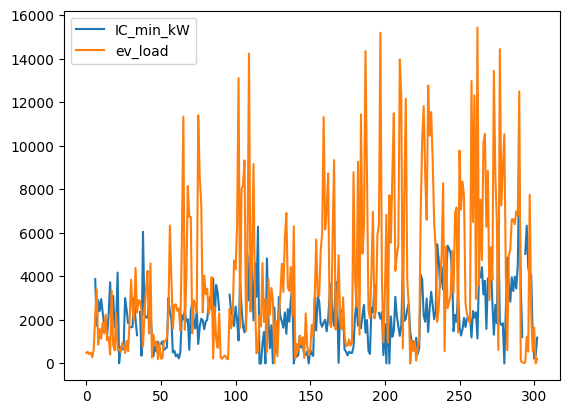

In [8]:
feeder_ev_aggregated_df = feeder_capacity_df.merge(feeder_ev_load_series, left_index=True, right_index=True)
feeder_ev_aggregated_df[['IC_min_kW', 'ev_load']].plot()

In [9]:
((feeder_ev_aggregated_df['ev_load'] > feeder_ev_aggregated_df['IC_min_kW']).sum() / len(feeder_ev_aggregated_df)) * 100
# 6% feeders are overloaded with EV adoption

np.float64(65.01650165016501)

In [200]:
feeder_disagg_df.head().to_clipboard()

In [10]:
feeder_disagg_df = feeder_block_map_df.div(feeder_block_map_df.sum(axis=1), axis=0)

In [11]:
capacity_by_block = {}
base_load_by_block = {}

for block in feeder_disagg_df.columns:
    # Multiply proportion by capacity for each feeder, then sum
    capacity_by_block[block] = (feeder_disagg_df[block] * feeder_capacity_df['IC_min_kW']).sum()
    base_load_by_block[block] = (feeder_disagg_df[block] * base_load_df['high_load_kw']).sum()

# Convert to a Series or DataFrame
capacity_series = pd.Series(capacity_by_block)
base_load_series = pd.Series(base_load_by_block)

In [119]:
df = ev_network_df.merge(capacity_series.rename("IC_min_kW"), how="left", left_on="geoid", right_index=True).merge(base_load_series.rename("base_load_kW"), how="left", left_on="geoid", right_index=True)
# df = df.merge(ev_load_df[['geoid_str', 'load']], how="left", left_on="geoid_str_", right_on="geoid_str")

In [120]:
df.columns

Index(['geoid_str_', 'INTPTLAT', 'INTPTLON', 'NEIGHBOURS', 'origin_chargers',
       'destination_chargers', 'origin_demand_(kW)', 'destination_demand_(kW)',
       'distance_km', 'geoid', 'neighbor_geoid', 'total_ev_load', 'IC_min_kW',
       'base_load_kW'],
      dtype='object')

<Axes: >

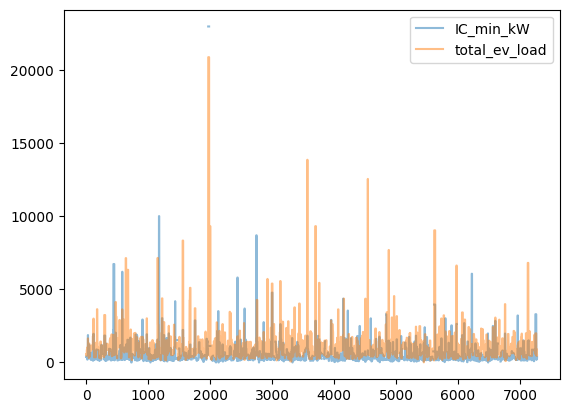

In [121]:
df[['IC_min_kW', 'total_ev_load']].plot(alpha=0.5)

In [122]:
def impute_load_data(df, column: str):
    # Step 1: Get rows with valid (non-zero, non-NaN) values
    valid_data = df[(df[column] > 0) & (df[column].notna())].copy()
    
    # Calculate the ratio of baseload to EV load
    valid_data['baseload_to_ev_ratio'] = (
        valid_data[column] / valid_data['total_ev_load']
    )
    
    # Step 2: Create bins for all rows based on total EV load
    df['ev_load_bin'] = pd.qcut(
        df['total_ev_load'], 
        q=10,
        labels=False, 
        duplicates='drop'
    )
    
    # Step 3: Calculate bin statistics from valid data
    bin_stats = valid_data.groupby(
        pd.qcut(valid_data['total_ev_load'], q=10, labels=False, duplicates='drop')
    )['baseload_to_ev_ratio'].agg(['mean', 'std', 'median'])
    
    # Step 4: Impute missing or zero values
    def impute_baseload(row):
        # Check if value is missing or zero
        if pd.isna(row[column]) or row[column] == 0:
            bin_idx = row['ev_load_bin']
            
            if bin_idx in bin_stats.index:
                # Sample from normal distribution using bin statistics
                ratio = np.random.normal(
                    bin_stats.loc[bin_idx, 'mean'],
                    bin_stats.loc[bin_idx, 'std']
                )
                # Ensure ratio is positive
                ratio = max(ratio, 0)
                return ratio * row['total_ev_load']
            else:
                # Fallback to overall median if bin not found
                return bin_stats['median'].median() * row['total_ev_load']
        else:
            return row[column]
    
    df[column] = df.apply(impute_baseload, axis=1)
    
    # Clean up temporary column
    df.drop('ev_load_bin', axis=1, inplace=True)

# Apply the function
impute_load_data(df, 'base_load_kW')
impute_load_data(df, 'IC_min_kW')

In [123]:
df['overload'] = -1 * (df['IC_min_kW'] - df['total_ev_load'])

In [124]:
import geopandas as gpd
census_blocks = gpd.read_file('/Users/lazlopaul/Desktop/sys_ms/mobility/final-project/OptimalChargerPlacement/data/Geography_Files/location_str_to_geoid_mapping.shp')


In [125]:
gdf = census_blocks.merge(df, left_on='GEOID', right_on='geoid', how='right', suffixes=('', '_y'))

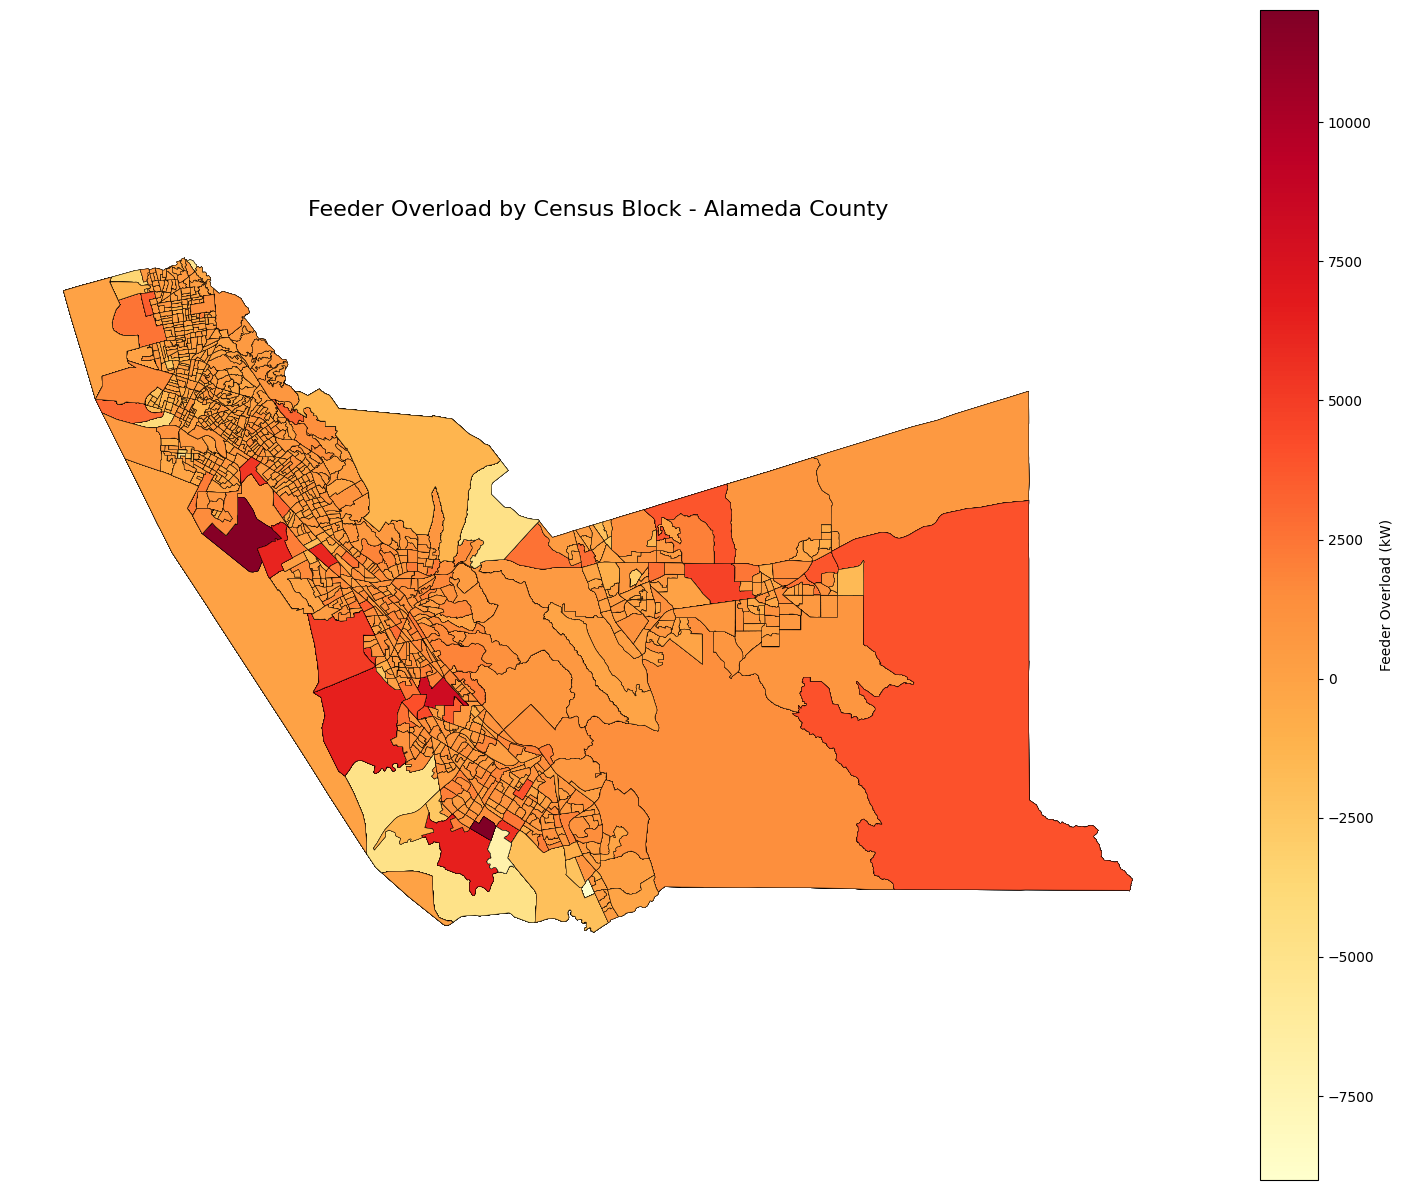

In [126]:
# # Merge with your capacity data
# blocks_unique = df.groupby('geoid').agg({
#     'overload': 'first'
# }).reset_index()

# # Merge on GEOID
# census_blocks_plotting = census_blocks.merge(
#     blocks_unique, 
#     left_on='GEOID', 
#     right_on='geoid', 
#     how='left'
# )

# Plot
fig, ax = plt.subplots(figsize=(15, 12))

gdf.plot(
    ax=ax,
    column='overload',
    cmap='YlOrRd',
    legend=True,
    edgecolor='black',
    linewidth=0.3,
    legend_kwds={
        'label': 'Feeder Overload (kW)',
        'orientation': 'vertical'
    }
)

plt.title('Feeder Overload by Census Block - Alameda County', fontsize=16)
plt.axis('off')
plt.tight_layout()
plt.show()

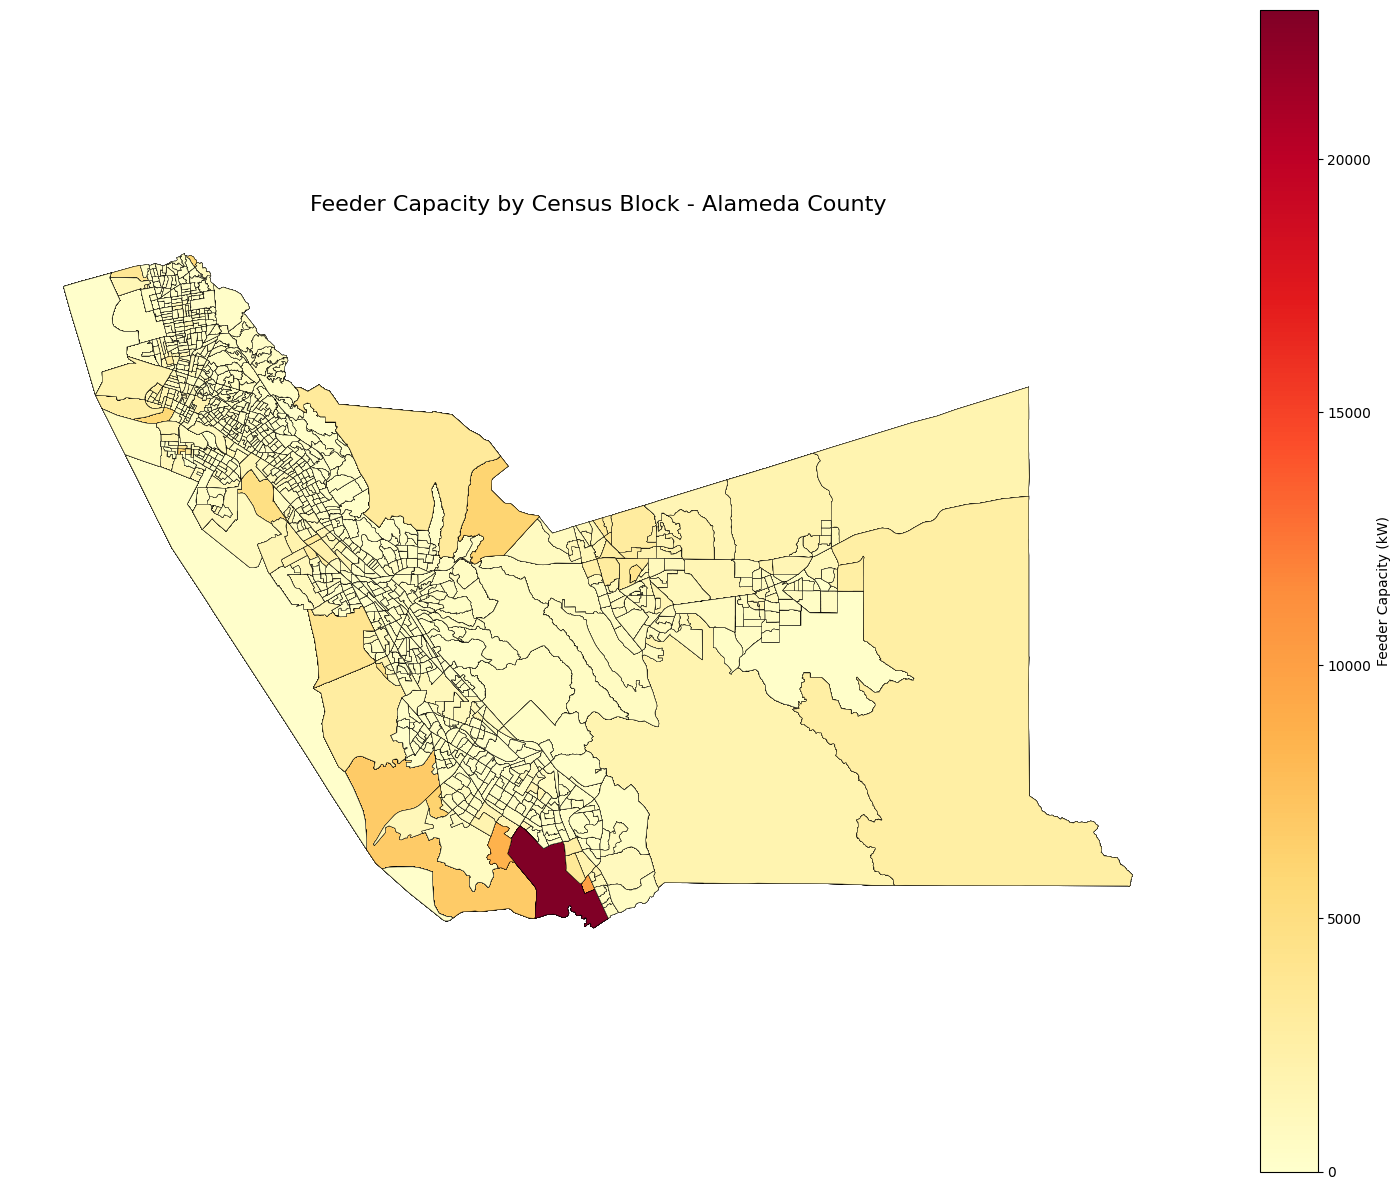

In [127]:
# Plot
fig, ax = plt.subplots(figsize=(15, 12))

# # Merge with your capacity data
# blocks_unique = df.groupby('geoid').agg({
#     'IC_min_kW': 'first'
# }).reset_index()

# # Merge on GEOID
# census_blocks_plotting = census_blocks.merge(
#     blocks_unique, 
#     left_on='GEOID', 
#     right_on='geoid', 
#     how='left'
# )

gdf.plot(
    ax=ax,
    column='IC_min_kW',
    cmap='YlOrRd',
    legend=True,
    edgecolor='black',
    linewidth=0.3,
    legend_kwds={
        'label': 'Feeder Capacity (kW)',
        'orientation': 'vertical'
    }
)

plt.title('Feeder Capacity by Census Block - Alameda County', fontsize=16)
plt.axis('off')
plt.tight_layout()
plt.show()

In [202]:
# (Overload / degree * distance)
gdf.head(2).to_clipboard()

In [204]:
# Calculate the sum of distances for each geoid
distance_sum = gdf.groupby('GEOID')['distance_km'].sum().reset_index()

# Rename the summed column for clarity
distance_sum.rename(columns={'distance_km': 'total_distance_to_neighbors_km'}, inplace=True)

# Merge this sum back into the original DataFrame
gdf = pd.merge(gdf, distance_sum, on='GEOID', how='left')

In [247]:
# First, calculate the degree (number of neighbors) for each geoid
degree_df = gdf.groupby('geoid').size().reset_index(name='degree')

# Merge degree back to main dataframe
gdf = gdf.merge(degree_df, on='geoid', how='left', suffixes=('', '_y'))

# Calculate the new metric
max_overload = gdf['overload'].max()

# converting kW to MW by dividing by 10^3

# gdf['transfer_metric'] = ( max_overload - (gdf['overload'] / (gdf['degree'] * gdf['distance_km']))) / 10**3 
gdf['transfer_metric'] = ( (gdf['overload'] * gdf['total_distance_to_neighbors_km'] / (gdf['degree'] * gdf['distance_km']))) / 10**3 
gdf['transfer_metric'] = gdf['transfer_metric'].max() - gdf['transfer_metric']
gdf = gdf.dropna(subset=['transfer_metric'])

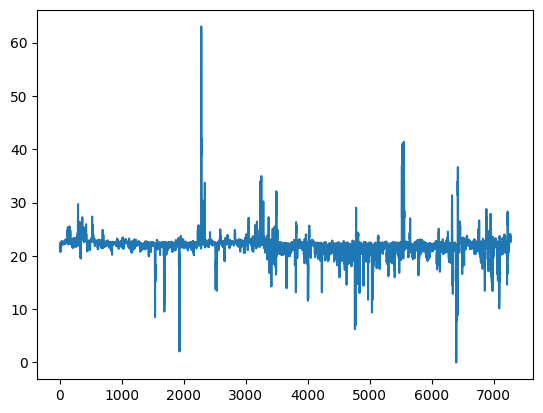

In [248]:
plt.plot(gdf.sort_values(by = 'geoid')['transfer_metric'].values)

In [249]:
# Build graph with normalized weights
# increasing weights to MW
G = nx.Graph()
for _, row in gdf.iterrows():
    G.add_edge(
        row['geoid'],
        row['neighbor_geoid'],
        weight=row['transfer_metric']
    )

# Calculate closeness centrality
closeness = nx.closeness_centrality(G, distance='weight', wf_improved=True)

# Convert to dataframe
closeness_centrality_df = pd.DataFrame(list(closeness.items()), 
                            columns=['geoid', 'closeness_centrality'])

In [250]:
gdf = gdf.merge(
    closeness_centrality_df,
    left_on='GEOID',
    right_on='geoid',
    how='left',
    suffixes=('', '_y')
)

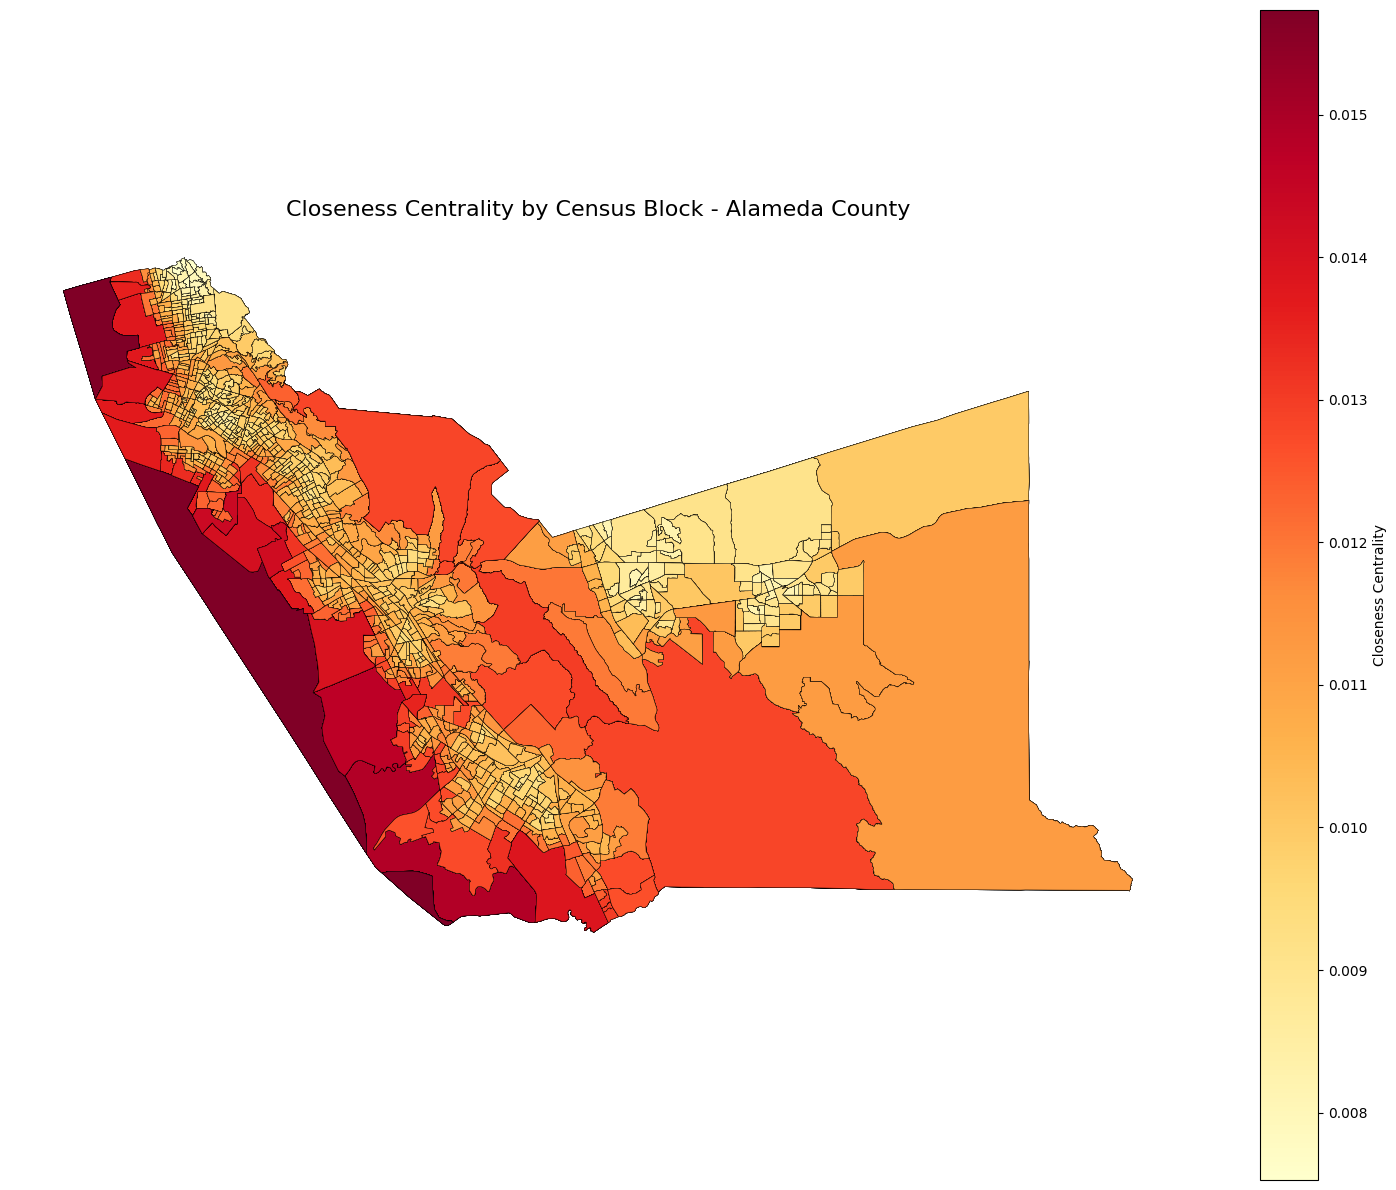

Centrality Statistics:
Mean: 0.0058
Median: 0.0058
Min: 0.0041
Max: 0.0089

Top 20 most central blocks:
             geoid  closeness_centrality
425   060019900000              0.008897
1094  060014090002              0.008468
426   060014371011              0.008368
424   060014415034              0.008308
453   060014324003              0.008137
182   060014090003              0.008103
539   060014371014              0.008005
269   060014283014              0.007972
865   060014403321              0.007916
261   060014017003              0.007844
527   060014334003              0.007788
3     060014220001              0.007750
1012  060014403331              0.007744
513   060014251012              0.007716
423   060019819001              0.007683
961   060014384002              0.007683
450   060014324001              0.007659
905   060014287002              0.007655
434   060014415032              0.007634
187   060014284001              0.007607


In [251]:
fig, ax = plt.subplots(figsize=(15, 12))

gdf.plot(
    ax=ax,
    column='closeness_centrality',
    cmap='YlOrRd',  # or 'viridis', 'plasma', 'coolwarm'
    legend=True,
    edgecolor='black',
    linewidth=0.3,
    legend_kwds={
        'label': 'Closeness Centrality',
        'orientation': 'vertical'
    }
)


plt.title('Closeness Centrality by Census Block - Alameda County', fontsize=16)
plt.axis('off')
plt.tight_layout()
plt.show()

# Optional: Print statistics
print(f"Centrality Statistics:")
print(f"Mean: {closeness_centrality_df['closeness_centrality'].mean():.4f}")
print(f"Median: {closeness_centrality_df['closeness_centrality'].median():.4f}")
print(f"Min: {closeness_centrality_df['closeness_centrality'].min():.4f}")
print(f"Max: {closeness_centrality_df['closeness_centrality'].max():.4f}")
print(f"\nTop 20 most central blocks:")
print(closeness_centrality_df.nlargest(20, 'closeness_centrality'))

In [273]:
# grid build score is ( - overload / centrality)
gdf['grid_build_score'] =  - gdf['overload'] * gdf['closeness_centrality'] # df['grid_build_score'] =  - df['overload'] / 10**3 /df['closeness_centrality']
# df = df.merge(
#     census_blocks,
#     left_on='geoid',
#     right_on='GEOID',
#     how='left'
# )

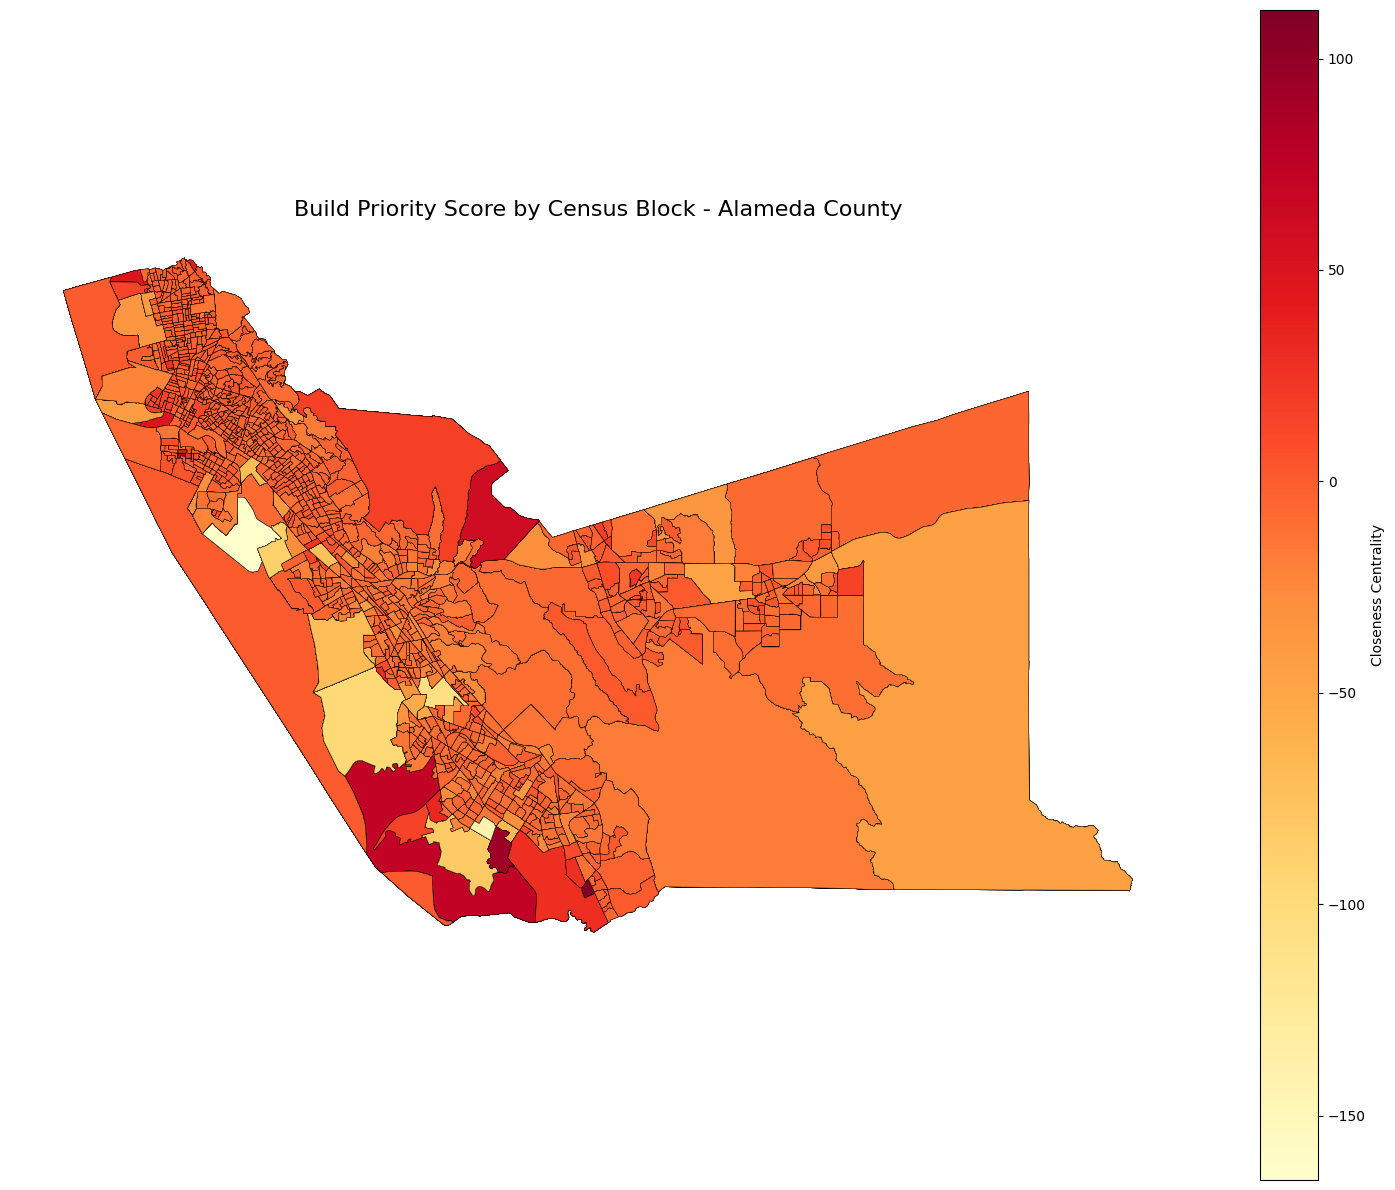

Centrality Statistics:
Mean: -6.5023
Median: -4.9204
Min: -165.1652
Max: 111.4701


In [274]:
fig, ax = plt.subplots(figsize=(15, 12))

gdf.plot(
    ax=ax,
    column='grid_build_score',
    cmap='YlOrRd',  # or 'viridis', 'plasma', 'coolwarm'
    legend=True,
    edgecolor='black',
    linewidth=0.3,
    legend_kwds={
        'label': 'Closeness Centrality',
        'orientation': 'vertical'
    }
)


plt.title('Build Priority Score by Census Block - Alameda County', fontsize=16)
plt.axis('off')
plt.tight_layout()
plt.show()

# Optional: Print statistics
print(f"Centrality Statistics:")
print(f"Mean: {gdf['grid_build_score'].mean():.4f}")
print(f"Median: {gdf['grid_build_score'].median():.4f}")
print(f"Min: {gdf['grid_build_score'].min():.4f}")
print(f"Max: {gdf['grid_build_score'].max():.4f}")

In [261]:
print(f"\nTop 20 most prioritized for building:")
print(gdf[['geoid', 'grid_build_score']].drop_duplicates().nlargest(20, 'grid_build_score'))


Top 20 most prioritized for building:
             geoid  grid_build_score
2009  060014278001        781.858068
1174  060014415031        727.952849
1038  060014211001        721.434388
5982  060014279004        540.782623
2745  060014446022        532.934125
3053  060014278004        493.597011
6220  060014301013        377.392633
1037  060014211001        371.551473
1435  060014507431        369.385704
7091  060014278002        350.627659
6947  060014278005        332.384336
2439  060019820001        329.486209
439   060014415034        325.615195
5596  060014283012        324.210727
6777  060014273004        313.660951
2129  060014502003        300.354949
5612  060014272005        288.370504
6948  060014278005        283.740206
2010  060014278001        281.437323
5983  060014279004        274.715904


In [258]:
print(f"\nTop 20 least overloaded blocks:")
print(gdf[['geoid', 'overload']].drop_duplicates().nsmallest(20, 'overload'))


Top 20 least overloaded blocks:
             geoid     overload
1174  060014415031 -9008.049261
2009  060014278001 -7739.331416
2745  060014446022 -7045.487291
3053  060014278004 -5811.938198
5982  060014279004 -5435.157393
1038  060014211001 -5430.166635
439   060014415034 -4845.514304
6220  060014301013 -4805.564665
2439  060019820001 -4018.994176
5596  060014283012 -3974.702247
7091  060014278002 -3759.888471
6947  060014278005 -3563.160605
2555  060014203022 -3513.577877
6777  060014273004 -3362.849464
5612  060014272005 -3072.986533
6948  060014278005 -3041.695452
1435  060014507431 -2986.549040
1037  060014211001 -2796.631886
2010  060014278001 -2785.846697
5983  060014279004 -2761.043192


In [268]:
set(gdf[['geoid', 'overload']].drop_duplicates().nsmallest(10, 'overload').index).intersection(set(gdf[['geoid', 'grid_build_score']].drop_duplicates().nlargest(10, 'grid_build_score').index))

{1038, 1174, 2009, 2745, 3053, 5982, 6220}

In [265]:
set(gdf[['geoid', 'overload']].drop_duplicates().nsmallest(20, 'overload').index).intersection(set(gdf[['geoid', 'grid_build_score']].drop_duplicates().nlargest(20, 'grid_build_score').index))

{439,
 1037,
 1038,
 1174,
 1435,
 2009,
 2010,
 2439,
 2745,
 3053,
 5596,
 5612,
 5982,
 5983,
 6220,
 6777,
 6947,
 6948,
 7091}

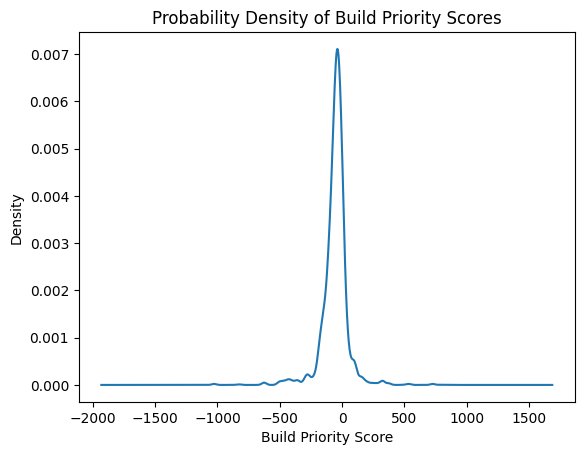

In [246]:
gdf['grid_build_score'].plot(kind='kde')
plt.title('Probability Density of Build Priority Scores')
plt.xlabel('Build Priority Score')
plt.ylabel('Density')
plt.show()

In [234]:
from keplergl import KeplerGl

# # Create map
# map_1 = KeplerGl(height=600)

# # Add your data
# map_1.add_data(data=census_blocks_plotting, name='census_blocks')

# # Display
# map_1

In [235]:
# import json
# kepler_config = map_1.config

# # Save the configuration to a JSON file
# with open('keplergl_config.json', 'w') as f:
#     json.dump(kepler_config, f, indent=4)


In [236]:
# Scoring of locations 
# POI Density / Closeness Centrality

In [237]:
# Key Metric - Potential Build Locations 
# Network distributing overload to adjacent zones based on their accessibility. 
# Ratio of closeness centrality for this weighted network and the am

In [238]:
from sympy import symbols, exp, solve

# Define symbols
t, m, p, q, y = symbols('t m p q y')

# Define the equation
equation = y - m * (1 - exp(-(p + q)*t)) / (1 + (q/p) * exp(-(p + q)*t))

# Solve for q symbolically
m_solutions = solve(equation, m)

# Then substitute your values
t_val, p_val, y_val, q_val = 10,  0.0015, 207, 0.290
numerical_solutions = [sol.subs({t: t_val, q: q_val, p: p_val, y: y_val}) 
                       for sol in m_solutions]
print(numerical_solutions)
m_val = numerical_solutions[0]

[2512.42910723638]


In [239]:
y_solutions = solve(equation, y)
ev_adoption = []
for i in range(0,10):
    t_val = i + 1
    numerical_solutions = [sol.subs({t: t_val, m: m_val, q: q_val, p: p_val}) 
                           for sol in y_solutions]
    print(f"At time {t_val}, EV Adoption: {numerical_solutions[0]}")
    ev_adoption.append(numerical_solutions[0])

At time 1, EV Adoption: 4.36781627298889
At time 2, EV Adoption: 10.1901376105715
At time 3, EV Adoption: 17.9407558685238
At time 4, EV Adoption: 28.2396151804355
At time 5, EV Adoption: 41.8916044294669
At time 6, EV Adoption: 59.9307838361008
At time 7, EV Adoption: 83.6667650170049
At time 8, EV Adoption: 114.725997382602
At time 9, EV Adoption: 155.074503032827
At time 10, EV Adoption: 207.000000000000


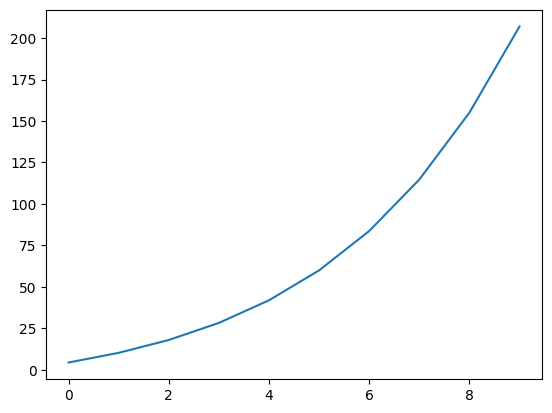

In [150]:
plt.plot(ev_adoption)

In [151]:
import pytidycensus 
import os 
os.environ["CENSUS_API_KEY"] = "576fa283036ef8d4d58d89379a346607f1db9fb1"


In [152]:
df

,geoid_str_,INTPTLAT,INTPTLON,NEIGHBOURS,origin_chargers,destination_chargers,origin_demand_(kW),destination_demand_(kW),distance_km,geoid,neighbor_geoid,total_ev_load,IC_min_kW,base_load_kW,overload
0,"2 (Tract 4232, Alameda, CA)",37.862497,-122.293241,"1 (Tract 4233, Alameda, CA)",[333026],None,568.288007,274.272001,0.760447,060014232002,060014233001,568.288007,398.387445,755.672229,169.900562
1,"2 (Tract 4232, Alameda, CA)",37.862497,-122.293241,"4 (Tract 4231, Alameda, CA)",[333026],None,568.288007,433.504001,0.668007,060014232002,060014231004,568.288007,398.387445,755.672229,169.900562
2,"2 (Tract 4232, Alameda, CA)",37.862497,-122.293241,"1 (Tract 4220, Alameda, CA)",[333026],"[161015, 205385, 220218, 220219, 308753, 32132...",568.288007,2937.020025,0.823073,060014232002,060014220001,568.288007,398.387445,755.672229,169.900562
3,"2 (Tract 4232, Alameda, CA)",37.862497,-122.293241,"3 (Tract 4231, Alameda, CA)",[333026],None,568.288007,178.240000,0.667594,060014232002,060014231003,568.288007,398.387445,755.672229,169.900562
4,"2 (Tract 4232, Alameda, CA)",37.862497,-122.293241,"2 (Tract 4231, Alameda, CA)",[333026],None,568.288007,637.020002,0.707463,060014232002,060014231002,568.288007,398.387445,755.672229,169.900562
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7271,"1 (Tract 4323, Alameda, CA)",37.734870,-122.167514,"3 (Tract 4104, Alameda, CA)",None,[312147],490.880003,928.864010,0.667486,060014323001,060014104003,490.880003,346.404017,736.878679,144.475985
7272,"1 (Tract 4323, Alameda, CA)",37.734870,-122.167514,"3 (Tract 4323, Alameda, CA)",None,None,490.880003,1464.864024,0.686872,060014323001,060014323003,490.880003,346.404017,736.878679,144.475985
7273,"1 (Tract 4323, Alameda, CA)",37.734870,-122.167514,"2 (Tract 4323, Alameda, CA)",None,None,490.880003,255.136003,0.319092,060014323001,060014323002,490.880003,346.404017,736.878679,144.475985
7274,"1 (Tract 4323, Alameda, CA)",37.734870,-122.167514,"4 (Tract 4093, Alameda, CA)",None,None,490.880003,335.424005,0.550617,060014323001,060014093004,490.880003,346.404017,736.878679,144.475985


In [39]:
# Variable for Median Household Income: B19013_001E
variable = "B19013_001E"
year = 2023 
census_income_df = pytidycensus.get_acs(
    geography="block group",
    variables=variable,
    state="06", # California
    county="001", # Alameda County
    year=year,
    output="wide"
)

Getting data from the 2019-2023 5-year ACS


In [40]:
census_income_df.rename(columns={
    'B19013_001_moe': 'median_household_income'
}, inplace=True)
gdf = gdf.merge(census_income_df[['GEOID', 'median_household_income']], left_on='geoid', right_on='GEOID', how='left')

In [41]:
gdf.median_household_income.fillna(gdf.median_household_income.mean(), inplace=True)

/var/folders/ff/05grcg517lbgzyz6gz1m5x2c0000gq/T/ipykernel_79658/1357008762.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  gdf.median_household_income.fillna(gdf.median_household_income.mean(), inplace=True)
/var/folders/ff/05grcg517lbgzyz6gz1m5x2c0000gq/T/ipykernel_79658/1357008762.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_s

In [42]:
lower_income_threshold = gdf.median_household_income.quantile(0.33)
upper_income_threshold = gdf.median_household_income.quantile(0.66)

adoption_parameters = {'low': {'p': 0.00118, 'q': 0.303},
                       'medium': {'p': 0.00222, 'q': 0.254},
                      'high': {'p': 0.00174, 'q': 0.231}}

In [43]:
def calculate_ev_adoption(df):
    """
    Calculate EV adoption based on household income and predefined parameters.
    
    Parameters:
    df (DataFrame): DataFrame containing 'median_household_income' and 'geoid'.
    
    Returns:
    DataFrame: Updated DataFrame with 'ev_adoption' column.
    """
    def adoption_rate(row):
        if row['median_household_income'] <= lower_income_threshold:
            p, q = adoption_parameters['low']['p'], adoption_parameters['low']['q']
        elif row['median_household_income'] <= upper_income_threshold:
            p, q = adoption_parameters['medium']['p'], adoption_parameters['medium']['q']
        else:
            p, q = adoption_parameters['high']['p'], adoption_parameters['high']['q']
        
        return p,q
    
    ev_adoption = {}
    for index, row in df.iterrows():
        p_val, q_val = adoption_rate(row)

        t_val = 10

        y_val = row['total_ev_load']  # using ev load as proxy for adoption/market size
        # Solve the equation for m
        m_val = [sol.subs({t: t_val, q: q_val, p: p_val, y: y_val}) 
                            for sol in m_solutions][0]
        
        
        y_solutions = solve(equation, y)
        ev_adoption[row['geoid']] = []
        for i in range(0,10):
            t_val = i + 1
            numerical_solutions = [sol.subs({t: t_val, m: m_val, q: q_val, p: p_val}) 
                                for sol in y_solutions]
            ev_adoption[row['geoid']].append(float(numerical_solutions[0]))

    return pd.DataFrame(ev_adoption, index=range(1, 11)).T.rename(columns={i: f'time_{i}' for i in range(1, 11)})

In [44]:
ev_adoption_df = calculate_ev_adoption(gdf)

In [45]:
ev_adoption_df.columns = pd.date_range(start='2025', end='2035', freq='Y')

/var/folders/ff/05grcg517lbgzyz6gz1m5x2c0000gq/T/ipykernel_79658/1186131789.py:1: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  ev_adoption_df.columns = pd.date_range(start='2025', end='2035', freq='Y')


In [74]:
for i in range(1,11):
    print(i)

1
2
3
4
5
6
7
8
9
10


Text(0.5, 1.0, 'EV Adoption Projections for Example Census Block Groups')

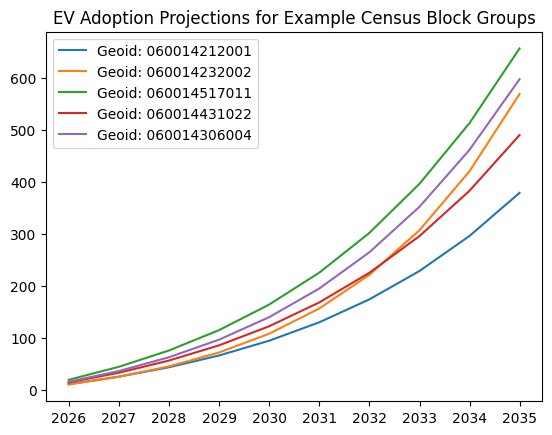

In [198]:
from random import random
for i in range(5):
    ind = np.floor(random() * len(ev_adoption_df))
    plt.plot(ev_adoption_df.iloc[int(ind)], label=f'Geoid: {ev_adoption_df.index[int(ind)]}')

plt.legend()
plt.title('EV Adoption Projections for Example Census Block Groups')

In [47]:
melted_df = pd.melt(
    ev_adoption_df.reset_index().rename(columns={'index': 'geoid'}),
    ignore_index=False,
    id_vars=['geoid'],
    value_vars=ev_adoption_df.columns,
    var_name='Time_Step',
    value_name='year_ev_load',
    
)

melted_df

,geoid,Time_Step,year_ev_load
0,060014232002,2025-12-31 00:00:00,10.899323
1,060014043002,2025-12-31 00:00:00,13.758958
2,060014062022,2025-12-31 00:00:00,16.633298
3,060014327003,2025-12-31 00:00:00,31.034792
4,060014415232,2025-12-31 00:00:00,14.342854
...,...,...,...
1129,060014218001,2034-12-31 00:00:00,607.680010
1130,060014301021,2034-12-31 00:00:00,1989.624012
1131,060014202003,2034-12-31 00:00:00,462.016004
1132,060014203011,2034-12-31 00:00:00,914.016006


In [49]:
# coming up with a dataframe for analysis over time 
tracking_overload_df = gdf.copy()

In [50]:
tracking_overload_df = tracking_overload_df.drop_duplicates(subset=['geoid','neighbor_geoid'])

In [51]:
tracking_overload_df = tracking_overload_df.merge(melted_df, left_on='geoid', right_on='geoid', how='outer')
tracking_overload_df['overload'] = tracking_overload_df['total_ev_load'] - tracking_overload_df['IC_min_kW']
tracking_overload_df['year_overload'] = tracking_overload_df['year_ev_load'] - tracking_overload_df['IC_min_kW']

In [153]:
tracking_overload_df['year_min_overload'] = tracking_overload_df.groupby('Time_Step')['year_overload'].transform('min')
tracking_overload_df['year_max_overload'] = tracking_overload_df.groupby('Time_Step')['year_overload'].transform('max')

In [154]:
tracking_overload_df.groupby('Time_Step').get_group('2034-12-31')['year_overload'].min()

np.float64(-9008.049260766182)

<Axes: ylabel='Density'>

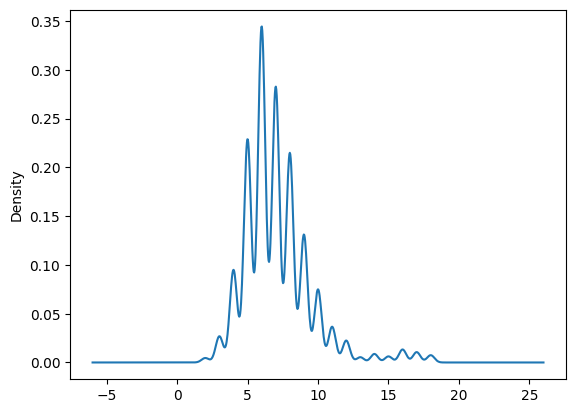

In [155]:
tracking_overload_df.degree.plot(kind='kde')

In [157]:
# trying max minus
# tracking_overload_df['year_transfer_metric'] = ((tracking_overload_df['year_overload'] / (tracking_overload_df['degree'] * tracking_overload_df['distance_km'])) - tracking_overload_df['year_min_overload']) / 10**3 
tracking_overload_df['year_transfer_metric'] = ( tracking_overload_df['year_max_overload'] - (tracking_overload_df['year_overload'] / (tracking_overload_df['degree'] * tracking_overload_df['distance_km']))) / 10**3
# closeness_df = tracking_overload_df.dropna(subset=['year_transfer_metric'])

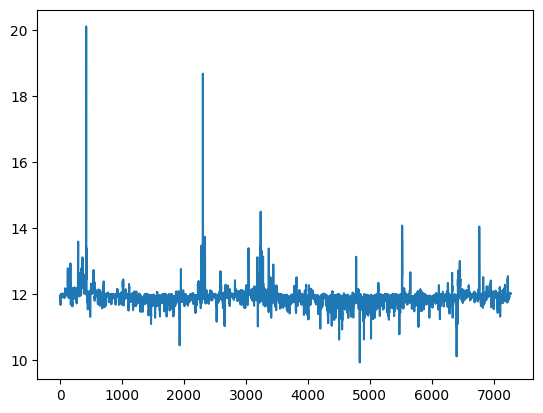

In [158]:
plt.plot(tracking_overload_df.groupby('Time_Step').get_group('2034-12-31').sort_values(by = 'geoid')['year_transfer_metric'].values)

In [159]:
tracking_overload_df.groupby('Time_Step').get_group('2034-12-31').sort_values(by = 'geoid')['year_transfer_metric'].values

array([11.95354522, 11.93075154, 11.94467464, ..., 12.01500723,
       12.01487537, 12.01511372], shape=(7276,))

In [160]:
build_scores = []
for group, closeness_df_group in tracking_overload_df.reset_index().groupby('Time_Step'):
    # calculating build score for each year 
    # closeness_df_group['year_transfer_metric'] = ((closeness_df_group['year_overload'] / (closeness_df_group['degree'] * closeness_df_group['distance_km'])) - closeness_df_group['year_min_overload']) / 10**3 
    G = nx.Graph()
    for _, row in closeness_df_group.iterrows():
        G.add_edge(
            row['geoid'],
            row['neighbor_geoid'],
            weight=row['year_transfer_metric']
        )

    # Calculate closeness centrality
    closeness = nx.closeness_centrality(G, distance='weight', wf_improved=True)

    # Convert to dataframe
    closeness_centrality_df = pd.DataFrame(list(closeness.items()), 
                                columns=['geoid', 'year_closeness_centrality'])
    
    closeness_centrality_df = closeness_centrality_df.merge(
        closeness_df_group[['geoid', 'Time_Step','index']],
        on='geoid',
        how='left'
    )
    build_scores.append(closeness_centrality_df)
    

<Axes: ylabel='Density'>

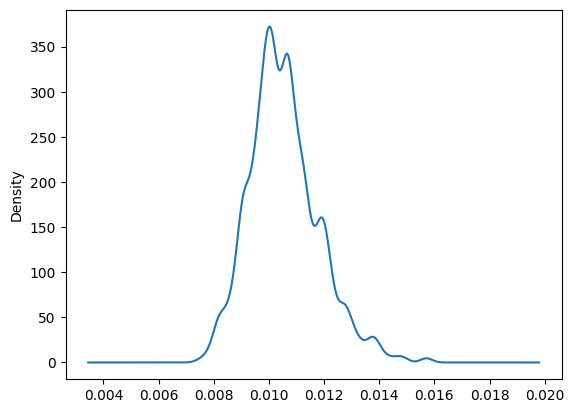

In [180]:
build_scores[-1]['year_closeness_centrality'].plot(kind='kde')

<Axes: ylabel='Density'>

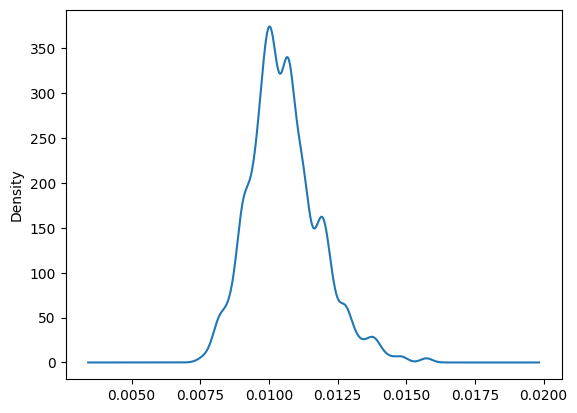

In [181]:
gdf['closeness_centrality'].plot(kind='kde')

In [182]:
build_scores_df = pd.concat(build_scores).drop_duplicates(subset=['Time_Step', 'geoid'])

In [183]:
build_scores_df['year_closeness_centrality'] = build_scores_df['year_closeness_centrality'].astype(float)

In [184]:
build_scores_df.sort_values(['geoid', 'Time_Step'], inplace=True)
closeness_df = build_scores_df.merge(tracking_overload_df, left_on=['geoid','Time_Step'], right_on=['geoid','Time_Step'], how='left')

In [185]:
closeness_df['year_closeness_centrality'] = closeness_df['year_closeness_centrality'].astype(float)

In [186]:
closeness_df.dropna(subset=['year_closeness_centrality'], inplace=True)

In [187]:

closeness_df['year_grid_build_score'] =  - closeness_df['year_overload'] / 10**3 / closeness_df['year_closeness_centrality']


<Axes: ylabel='Density'>

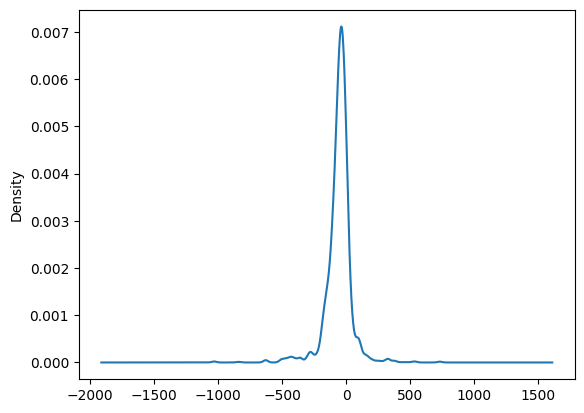

In [188]:
closeness_df.groupby('Time_Step').get_group('2034-12-31')['year_grid_build_score'].plot(kind='kde')

In [189]:
yearly_overload_kepler_df = closeness_df.drop(['neighbor_geoid', 'distance_km'], axis=1).drop_duplicates(subset =['geoid', 'Time_Step']).dropna(subset=['year_grid_build_score'])

{'whiskers': [<matplotlib.lines.Line2D at 0x3a47bef90>,
 'caps': [<matplotlib.lines.Line2D at 0x3a47bde90>,
 'boxes': [<matplotlib.lines.Line2D at 0x3a474f0d0>],
 'medians': [<matplotlib.lines.Line2D at 0x3a47bfe90>],
 'fliers': [<matplotlib.lines.Line2D at 0x3a36d24d0>],
 'means': []}

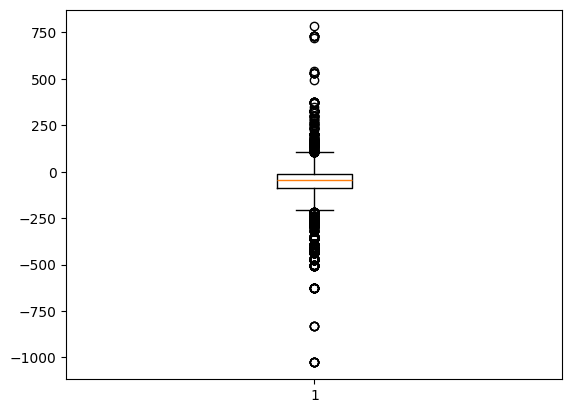

In [190]:
plt.boxplot(gdf['grid_build_score'])

{'whiskers': [<matplotlib.lines.Line2D at 0x3a4683450>,
 'caps': [<matplotlib.lines.Line2D at 0x3a45d30d0>,
 'boxes': [<matplotlib.lines.Line2D at 0x3a4683bd0>],
 'medians': [<matplotlib.lines.Line2D at 0x3a45d0150>],
 'fliers': [<matplotlib.lines.Line2D at 0x3a45d3290>],
 'means': []}

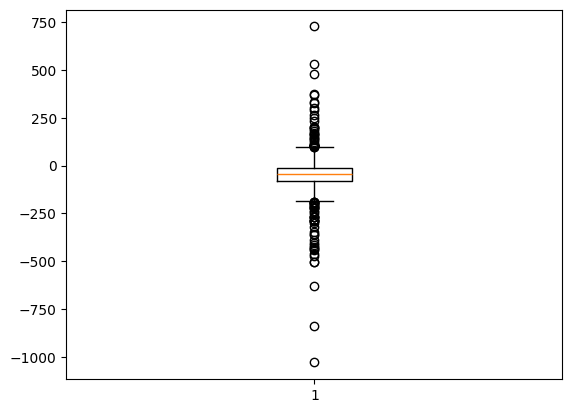

In [191]:
plt.boxplot(yearly_overload_kepler_df.groupby('Time_Step').get_group('2034-12-31')['year_grid_build_score'])

In [192]:
# Create map
map_1 = KeplerGl(height=600)

# Add your data
map_1.add_data(data=yearly_overload_kepler_df, name='census_blocks')

User Guide: https://docs.kepler.gl/docs/keplergl-jupyter


In [193]:
map_1

TypeError: Object of type ndarray is not JSON serializable

KeplerGl(data={'census_blocks': {'index': [0, 8, 16, 24, 32, 40, 48, 56, 64, 72, 80, 85, 90, 95, 100, 105, 110…

In [73]:
# # Save the configuration to a JSON file
# kepler_config = map_1.config
# with open('keplergl_animation.json', 'w') as f:
#     json.dump(kepler_config, f, indent=4)


In [78]:
gdf.to_csv('ev-feeder-census-data.csv')

In [81]:
yearly_overload_kepler_df.to_csv('ev-adoption-data.csv')

/var/folders/ff/05grcg517lbgzyz6gz1m5x2c0000gq/T/ipykernel_79658/2193689522.py:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('Blues')(np.linspace(0.3, 0.9, n_plots))[::-1]


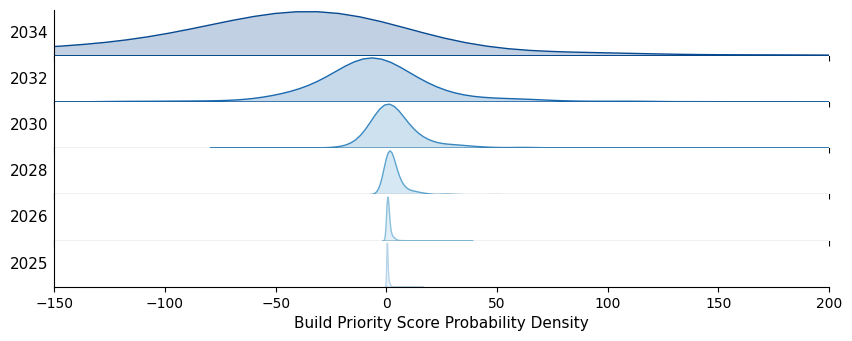

<Figure size 640x480 with 0 Axes>

In [175]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# Get unique years and select every other one
all_years = sorted(yearly_overload_kepler_df['Time_Step'].unique())
selected_years = all_years[::-1][::2] + [all_years[0]]  # Every other year, reversed, plus last year

# Create figure with subplots stacked vertically
n_plots = len(selected_years)
fig, axes = plt.subplots(n_plots, 1, figsize=(10, 0.6*n_plots), 
                         sharex=True)

# Remove spacing between subplots
plt.subplots_adjust(hspace=0)

# If only one plot, axes won't be an array
if n_plots == 1:
    axes = [axes]

# Create a color gradient from light to dark blue
colors = cm.get_cmap('Blues')(np.linspace(0.3, 0.9, n_plots))[::-1]

# Plot each year in its own subplot
for idx, year in enumerate(selected_years):
    ax = axes[idx]
    year_data = yearly_overload_kepler_df[yearly_overload_kepler_df['Time_Step'] == year]
    
    sns.kdeplot(data=year_data, x='year_grid_build_score', fill=True, ax=ax, color=colors[idx])
    ax.set_ylabel(f'{year.strftime("%Y")}', rotation=0, ha='right', va='center', fontsize=11)
    ax.set_xlabel('')
    
    # Remove y-ticks
    ax.set_yticks([])
    
    # Remove x-tick labels except for bottom plot
    if idx < n_plots - 1:
        # ax.set_xticklabels([])
        ax.tick_params(labelbottom=False)
    
    # Remove top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Set x-axis limits to focus on the peak
axes[0].set_xlim(-150, 200)  # Adjust this range as needed
axes[-1].tick_params(labelbottom=True, labelsize = 10)
# Add x-label only to bottom plot
axes[-1].set_xlabel('Build Priority Score Probability Density', fontsize=11)

plt.show()
plt.savefig('build-priority-score-evolution-kde.png')